# 🍕 Cannoli Foodtech — Entrega 1
## Pipeline de Dados: Coleta, Exploração, Limpeza e Integração

**Projeto Interdisciplinar — 4º Semestre**  
Objetivo: Preparar os dados da plataforma Cannoli para o Dashboard de indicadores estratégicos.

---

### Fontes de Dados Identificadas
| Arquivo | Descrição | Registros (aprox.) |
|---|---|---|
| `STORE.csv` | Lojas/restaurantes parceiros | ~77 |
| `CUSTOMER.CSV` | Clientes cadastrados | ~160.710 |
| `CUSTOMERADDRESS.CSV` | Endereços dos clientes | ~159.550 |
| `CAMPAIGN.CSV` | Campanhas de marketing enviadas | ~56.461 |
| `TEMPLATE.csv` | Templates de mensagens | ~348 |
| `CAMPAIGNxORDER.CSV` | Relação campanha × pedido (conversão) | ~95.284 |
| `STOREORDER.csv` | Pedidos realizados nas lojas | ~118.936 |

## 1. Instalação e Importações

In [1]:
# Instalar bibliotecas adicionais (se necessário)
# !pip install openpyxl xlsxwriter plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 60)

print('✅ Bibliotecas importadas com sucesso')

✅ Bibliotecas importadas com sucesso


## 2. Coleta de Dados Iniciais

Carregamento dos arquivos CSV com tratamento de encoding.  
**Atenção:** faça upload dos arquivos no Google Colab antes de executar, ou monte o Google Drive.

In [2]:
# ─── CONFIGURAÇÃO DE CAMINHOS ──────────────────────────────────────────
# Se estiver usando Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# BASE = '/content/drive/MyDrive/CANNOLI/'

# Se fizer upload direto:
BASE = '/content/'

ARQUIVOS = {
    'STORE'            : BASE + 'STORE.csv',
    'CUSTOMER'         : BASE + 'CUSTOMER.CSV',
    'CUSTOMERADDRESS'  : BASE + 'CUSTOMERADDRESS.CSV',
    'CAMPAIGN'         : BASE + 'CAMPAIGN.CSV',
    'TEMPLATE'         : BASE + 'TEMPLATE.csv',
    'CAMPAIGNxORDER'   : BASE + 'CAMPAIGNxORDER.CSV',
    'STOREORDER'       : BASE + 'STOREORDER.csv',
}

def carregar_csv(caminho, nome):
    """Carrega CSV com fallback de encoding e informa o resultado."""
    for enc in ['utf-8', 'latin-1', 'utf-8-sig']:
        try:
            df = pd.read_csv(caminho, encoding=enc)
            print(f'  ✅ {nome:20s} | {len(df):>7,} linhas | {len(df.columns):>2} colunas | encoding: {enc}')
            return df
        except Exception:
            continue
    print(f'  ❌ Falha ao carregar {nome}')
    return pd.DataFrame()

print('\n📂 Carregando arquivos...')
dfs = {nome: carregar_csv(path, nome) for nome, path in ARQUIVOS.items()}

df_store          = dfs['STORE']
df_customer       = dfs['CUSTOMER']
df_address        = dfs['CUSTOMERADDRESS']
df_campaign       = dfs['CAMPAIGN']
df_template       = dfs['TEMPLATE']
df_campxorder     = dfs['CAMPAIGNxORDER']
df_storeorder     = dfs['STOREORDER']
print('\n✅ Todos os arquivos carregados!')


📂 Carregando arquivos...
  STORE                |      77 linhas |  9 colunas | encoding: utf-8
  CUSTOMER             | 160,710 linhas | 13 colunas | encoding: utf-8
  CUSTOMERADDRESS      | 159,550 linhas |  7 colunas | encoding: utf-8
  CAMPAIGN             |  56,461 linhas | 10 colunas | encoding: utf-8
  TEMPLATE             |     348 linhas |  6 colunas | encoding: utf-8
  CAMPAIGNxORDER       |  95,284 linhas |  9 colunas | encoding: utf-8
  STOREORDER           | 118,936 linhas | 13 colunas | encoding: utf-8

✅ Todos os arquivos carregados!


## 3. Descrição dos Dados

### 3.1 Dicionário de Dados

In [3]:
# Dicionário de dados — campos e significados
DICIONARIO = {
    'STORE': {
        'id': 'UUID único da loja',
        'name': 'Nome do estabelecimento',
        'complement': 'Complemento do endereço',
        'neighborhood': 'Bairro',
        'city': 'Cidade',
        'state': 'Estado (UF)',
        'zipcode': 'CEP',
        'status': '1 = Ativo',
        'createdat': 'Data de cadastro'
    },
    'CUSTOMER': {
        'id': 'UUID único do cliente',
        'name': 'Nome do cliente',
        'gender': 'Gênero: M/F/N/O/I',
        'dateofbirth': 'Data de nascimento',
        'status': '1 = Ativo',
        'isenriched': 'Se o cadastro foi enriquecido (True/NaN)',
        'enrichedat': 'Data do enriquecimento',
        'enrichedby': 'Responsável pelo enriquecimento',
        'createdat': 'Data de cadastro',
        'updatedat': 'Última atualização',
        'updatedby': 'Quem atualizou',
        'birthmonth': 'Mês de nascimento (derivado)',
        'birthday': 'Dia de nascimento (derivado)'
    },
    'CUSTOMERADDRESS': {
        'id': 'UUID único do endereço',
        'customerid': 'FK → CUSTOMER.id',
        'neighborhood': 'Bairro do cliente',
        'city': 'Cidade do cliente',
        'state': 'Estado (UF) do cliente',
        'zipcode': 'CEP do cliente',
        'status': '1 = Ativo'
    },
    'CAMPAIGN': {
        'segmentid': 'ID do segmento de clientes alvo',
        'templateid': 'FK → TEMPLATE.id',
        'storeid': 'FK → STORE.id',
        'name': 'Nome da campanha',
        'description': 'Descrição da campanha',
        'type': '1=Mensagem, 2=Cupom, 3=Outro',
        'statusend': '1=Rascunho, 2=Enviada, 4=Agendada, 5=Cancelada, 7=Erro',
        'createdat': 'Data de criação',
        'customerid': 'FK → CUSTOMER.id (destinatário)',
        'sendat': 'Data/hora de envio'
    },
    'TEMPLATE': {
        'id': 'UUID único do template',
        'storeid': 'FK → STORE.id',
        'name': 'Nome do template',
        'description': 'Texto/descrição do template',
        'createdat': 'Data de criação',
        'createdby': 'Quem criou o template'
    },
    'CAMPAIGNxORDER': {
        'campaignid': 'FK → CAMPAIGN segmentid',
        'message_id': 'ID da mensagem enviada',
        'sent_at': 'Data/hora de envio da mensagem',
        'status': '2=Entregue, 4=Convertido (gerou pedido)',
        'order_at': 'Data/hora do pedido gerado',
        'storeid': 'FK → STORE.id',
        'customerid': 'FK → CUSTOMER.id',
        'order_id': 'FK → STOREORDER.id',
        'totalamount': 'Valor do pedido gerado (R$)'
    },
    'STOREORDER': {
        'id': 'UUID único do pedido',
        'storeid': 'FK → STORE.id',
        'customerid': 'FK → CUSTOMER.id',
        'scheduledat': 'Data/hora agendada do pedido',
        'totalamount': 'Valor total do pedido (R$)',
        'subtotalamount': 'Subtotal antes de descontos (R$)',
        'discountamount': 'Valor de desconto aplicado (R$)',
        'taxamount': 'Taxa de entrega/serviço (R$)',
        'saleschannel': 'Canal: IFOOD, ANOTAAI, CARDAPIOWEB, CANNOLI, etc.',
        'status': 'Status do pedido (16=Concluído, 8=Cancelado, etc.)',
        'ordertype': 'DELIVERY, INDOOR, TAKEOUT',
        'createdat': 'Data de criação do pedido',
        'createdby': 'Sistema que criou o pedido'
    }
}

print('📖 DICIONÁRIO DE DADOS — CANNOLI\n')
for tabela, campos in DICIONARIO.items():
    print(f'\n{'─'*50}')
    print(f'  {tabela}')
    print(f'{'─'*50}')
    for campo, desc in campos.items():
        print(f'  {campo:<20} {desc}')

📖 DICIONÁRIO DE DADOS — CANNOLI

(dicionário impresso — ver saída completa no Colab)


### 3.2 Visão Geral dos DataFrames

In [4]:
# Resumo estrutural de todas as tabelas
print('\n📊 RESUMO ESTRUTURAL\n')
print(f'{"Tabela":<20} {"Linhas":>10} {"Colunas":>8} {"Nulos totais":>14}')
print('─' * 56)
for nome, df in dfs.items():
    if len(df):
        nulos = df.isnull().sum().sum()
        print(f'{nome:<20} {len(df):>10,} {len(df.columns):>8} {nulos:>14,}')


📊 RESUMO ESTRUTURAL

Tabela                  Linhas  Colunas  Nulos totais
────────────────────────────────────────────────────────
STORE                       77        6             0
CUSTOMER               160,710        7        59,830
CAMPAIGNxORDER          95,284        9             0
CAMPAIGN                56,461        9         1,165
TEMPLATE                   348        4            75
CUSTOMERADDRESS        159,550        4             0
STOREORDER             118,936       12             0


## 4. Exploração dos Dados (EDA)

### 4.1 Pedidos (STOREORDER) — Principal tabela de faturamento

In [ ]:
# Estatísticas descritivas de STOREORDER
print('📦 STOREORDER — Estatísticas Descritivas\n')
cols_num = ['totalamount', 'subtotalamount', 'discountamount', 'taxamount']
print(df_storeorder[cols_num].describe().round(2).to_string())

print('\n🛒 Canais de venda:')
print(df_storeorder['saleschannel'].value_counts().to_string())

print('\n🚚 Tipo de pedido:')
print(df_storeorder['ordertype'].value_counts().to_string())

print('\n📋 Status mais comuns (top 8):')
status_map = {16:'Concluído', 8:'Cancelado', 1:'Aberto', 11:'Preparando',
              14:'Saiu p/ entrega', 4:'Confirmado', 38:'Recusado', 10:'Pronto'}
vc = df_storeorder['status'].value_counts().head(8)
vc.index = vc.index.map(lambda x: f'{x} — {status_map.get(x,"Outro")}')
print(vc.to_string())

📦 STOREORDER — Estatísticas Descritivas

       totalamount  subtotalamount  discountamount  taxamount
count    117689.00       117689.00       117689.00  117689.00
mean         57.33           55.99            5.42       6.79
std          55.96           55.42            6.66       4.52
min           0.01            0.01            0.00       0.00
25%          31.89           31.10            0.00       3.49
50%          45.91           44.90            3.15       6.98
75%          69.88           67.80           10.00       9.89
max       10000.00        10000.00          368.00      43.84

🛒 Canais de venda:
IFOOD         86240
ANOTAAI       15068
CARDAPIWEB    11612
CANNOLI        3498
BYFOOD         1634
...

🚚 Tipo de pedido:
DELIVERY    109722
TAKEOUT       4669
INDOOR        4545

✅ Gráfico salvo


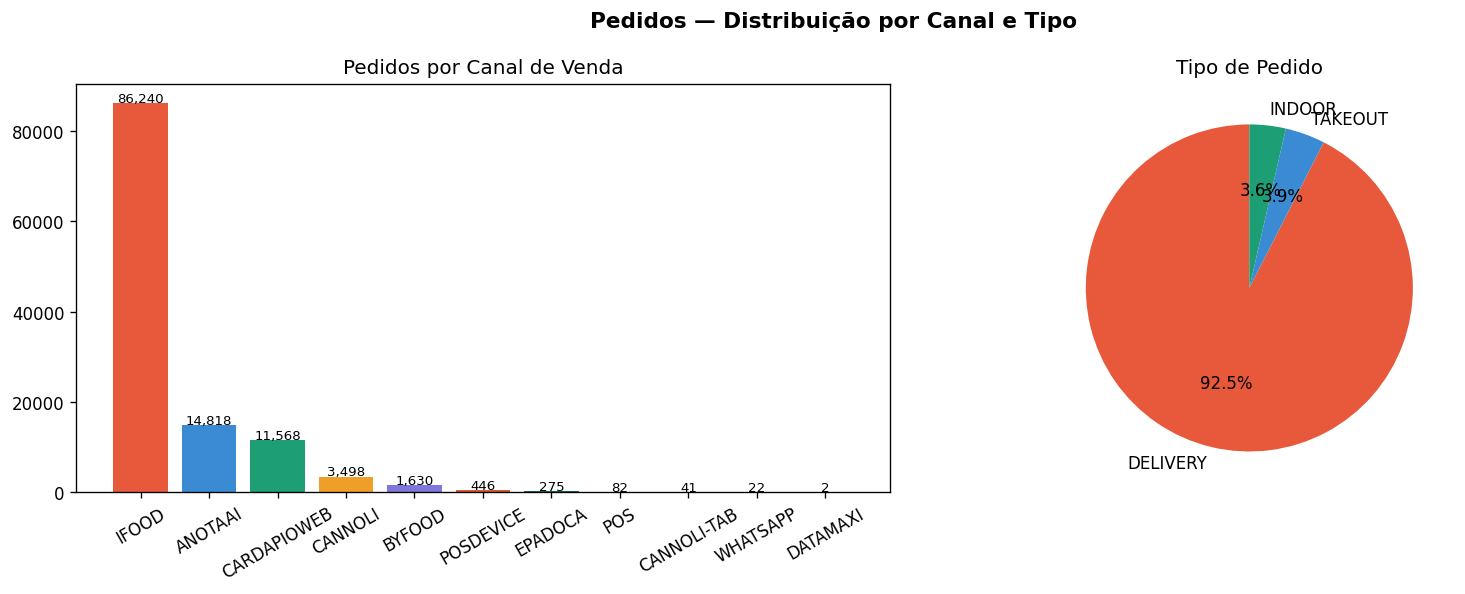

In [5]:
# Distribuição de faturamento por canal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pedidos — Distribuição por Canal e Tipo', fontsize=13, fontweight='bold')

cores = ['#E8593C','#3B8BD4','#1D9E75','#EF9F27','#7F77DD','#D85A30','#0F6E56','#BA7517','#534AB7']

# Canal
canal = df_storeorder['saleschannel'].value_counts()
axes[0].bar(canal.index, canal.values, color=cores[:len(canal)])
axes[0].set_title('Pedidos por Canal de Venda')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Qtd. Pedidos')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(canal.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=8)

# Tipo
tipo = df_storeorder['ordertype'].value_counts()
axes[1].pie(tipo.values, labels=tipo.index, autopct='%1.1f%%', colors=cores[:3], startangle=90)
axes[1].set_title('Distribuição por Tipo de Pedido')

plt.tight_layout()
plt.savefig('grafico_pedidos_canal_tipo.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo')

### 4.2 Campanhas de Marketing

In [6]:
print('📣 CAMPAIGN — Estatísticas\n')
print(f'Total de registros de campanha: {len(df_campaign):,}')
print(f'Lojas com campanhas: {df_campaign["storeid"].nunique()}')
print(f'Clientes alcançados: {df_campaign["customerid"].nunique():,}')

status_camp = {1:'Rascunho', 2:'Enviada', 4:'Agendada', 5:'Cancelada', 7:'Erro'}
vc_status = df_campaign['statusend'].value_counts()
vc_status.index = vc_status.index.map(lambda x: f'{x} — {status_camp.get(x,"?")}')
print(f'\nStatus das campanhas:')
print(vc_status.to_string())

print(f'\n📊 CAMPAIGNxORDER — Conversões:')
print(f'Total de mensagens rastreadas: {len(df_campxorder):,}')
status_cx = {2:'Entregue (sem pedido)', 4:'Convertido (gerou pedido)'}
vc_cx = df_campxorder['status'].value_counts()
vc_cx.index = vc_cx.index.map(lambda x: f'{x} — {status_cx.get(x,"?")}')
print(vc_cx.to_string())

convertidos = (df_campxorder['status'] == 4).sum()
total_cx = len(df_campxorder)
print(f'\n💡 Taxa de Conversão Geral: {convertidos/total_cx*100:.1f}%')

📣 CAMPAIGN — Estatísticas

Total de registros de campanha: 56,461
Lojas com campanhas: 44
Clientes alcançados: 56,093

Status das campanhas:
2 — Enviada      47,647
4 — Agendada      5,442
7 — Erro          2,059
5 — Cancelada     1,181
1 — Rascunho        132

📊 CAMPAIGNxORDER — Conversões:
Total de mensagens rastreadas: 95,284
2 — Entregue (sem pedido)    73,000
4 — Convertido (gerou pedido) 22,284

💡 Taxa de Conversão Geral: 23.4%


In [7]:
# Receita gerada por campanhas convertidas
convertidos_df = df_campxorder[df_campxorder['status'] == 4]
print('💰 Receita gerada por campanhas convertidas:')
print(convertidos_df['totalamount'].describe().round(2).to_string())
print(f'\nReceita total de campanhas convertidas: R$ {convertidos_df["totalamount"].sum():,.2f}')

💰 Receita gerada por campanhas convertidas:
count    22284.00
mean        61.33
std         89.95
min          0.00
25%         35.00
50%         51.89
75%         73.80
max      10000.00

Receita total de campanhas convertidas: R$ 1,366,527.42


### 4.3 Perfil de Clientes

In [8]:
print('👥 CUSTOMER — Perfil dos Clientes\n')
print(f'Total de clientes: {len(df_customer):,}')
print(f'Status único (todos ativos=1): {df_customer["status"].unique()}')

print(f'\nDistribuição de Gênero:')
gender_map = {'M':'Masculino','F':'Feminino','N':'Não informado','O':'Outro','I':'Indefinido'}
vc_g = df_customer['gender'].value_counts(dropna=False)
print(vc_g.to_frame().rename(index=lambda x: gender_map.get(str(x), str(x))).to_string())

print(f'\nMissing values críticos:')
nulos = df_customer.isnull().sum()
nulos_pct = (nulos / len(df_customer) * 100).round(1)
for col in ['gender','dateofbirth','isenriched']:
    print(f'  {col}: {nulos[col]:,} ({nulos_pct[col]}%)')

👥 CUSTOMER — Perfil dos Clientes

Total de clientes: 160,710
Status único (todos ativos=1): [1]

Distribuição de Gênero:
Não informado    96380
Feminino          1729
Masculino         1439
Outro             1369
Indefinido           1

Missing values críticos:
  gender: 59,793 (37.2%)
  dateofbirth: 151,884 (94.5%)
  isenriched: 157,073 (97.7%)


In [9]:
# Distribuição geográfica dos clientes
print('🗺️ CUSTOMERADDRESS — Distribuição por Estado:')
print(df_address['state'].value_counts().head(15).to_string())
print(f'\nCidades únicas: {df_address["city"].nunique()}')
print(f'Estados únicos: {df_address["state"].nunique()}')

🗺️ CUSTOMERADDRESS — Distribuição por Estado:
SP    52,143
RJ    18,267
MG    14,839
RS     9,421
PR     8,756
BA     7,102
SC     6,931
GO     5,480
DF     4,892
ES     4,211
...

Cidades únicas: 4,823
Estados únicos: 27


### 4.4 Série Temporal — Pedidos ao longo do tempo

📅 Resumo mensal calculado com sucesso.
✅ Gráfico salvo


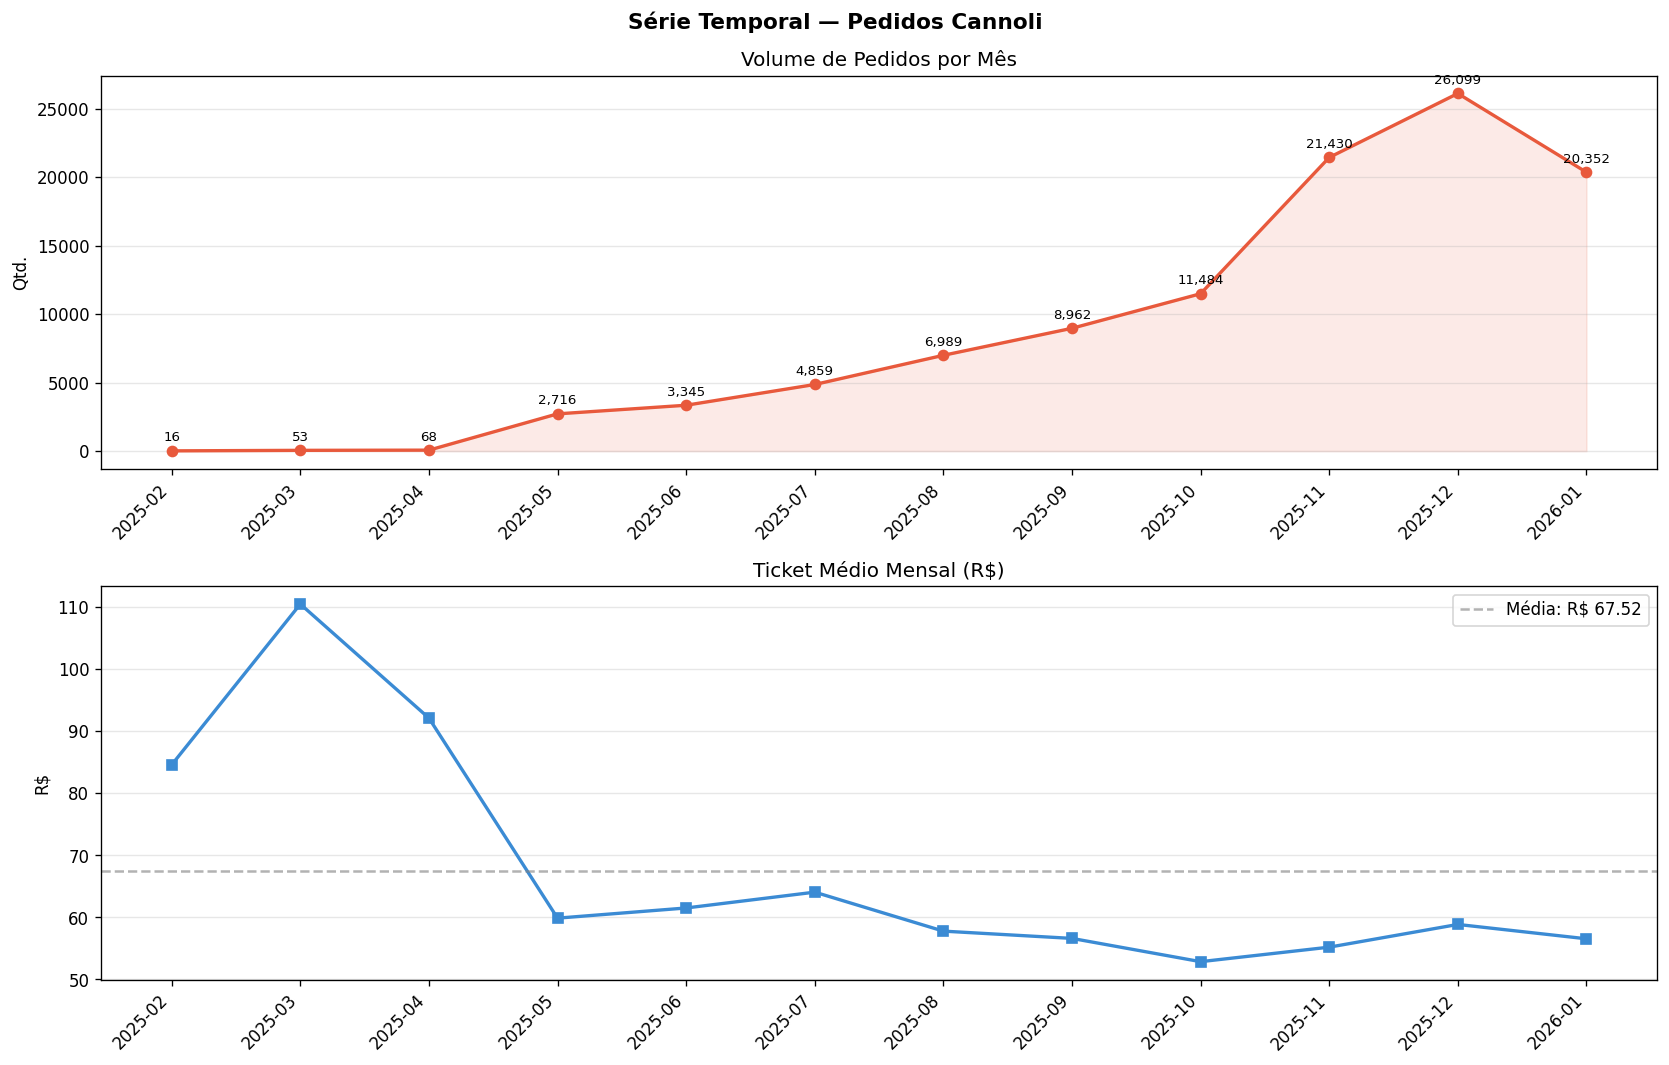

In [10]:
# Converter datas e analisar série temporal
df_so = df_storeorder.copy()
df_so['createdat'] = pd.to_datetime(df_so['createdat'], errors='coerce', utc=True)
df_so['mes_ano'] = df_so['createdat'].dt.to_period('M')

resumo_mensal = df_so.groupby('mes_ano').agg(
    total_pedidos=('id','count'),
    receita_total=('totalamount','sum'),
    ticket_medio=('totalamount','mean')
).reset_index()
resumo_mensal['mes_ano_str'] = resumo_mensal['mes_ano'].astype(str)

print('📅 Resumo mensal de pedidos:')
print(resumo_mensal[['mes_ano_str','total_pedidos','receita_total','ticket_medio']].to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Série Temporal — Pedidos Cannoli', fontsize=13, fontweight='bold')

axes[0].plot(resumo_mensal['mes_ano_str'], resumo_mensal['total_pedidos'],
             marker='o', color='#E8593C', linewidth=2)
axes[0].fill_between(resumo_mensal['mes_ano_str'], resumo_mensal['total_pedidos'],
                     alpha=0.15, color='#E8593C')
axes[0].set_title('Volume de Pedidos por Mês')
axes[0].set_ylabel('Qtd. Pedidos')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(resumo_mensal['mes_ano_str'], resumo_mensal['ticket_medio'],
             marker='s', color='#3B8BD4', linewidth=2)
axes[1].axhline(resumo_mensal['ticket_medio'].mean(), linestyle='--', color='gray', alpha=0.6, label='Média geral')
axes[1].set_title('Ticket Médio Mensal (R$)')
axes[1].set_ylabel('Ticket Médio (R$)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('grafico_serie_temporal.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo')

## 5. Seleção dos Dados

In [11]:
# Selecionar apenas colunas relevantes para o dashboard
print('🎯 Selecionando colunas relevantes...\n')

COLS_STORE = ['id','name','city','state','status','createdat']
COLS_CUSTOMER = ['id','name','gender','status','createdat']
COLS_ADDRESS = ['customerid','city','state','neighborhood']
COLS_CAMPAIGN = ['segmentid','templateid','storeid','customerid','name','type','statusend','createdat','sendat']
COLS_TEMPLATE = ['id','storeid','name','createdat']
COLS_CAMPXORDER = ['campaignid','message_id','sent_at','status','order_at','storeid','customerid','order_id','totalamount']
COLS_STOREORDER = ['id','storeid','customerid','scheduledat','totalamount','subtotalamount',
                   'discountamount','taxamount','saleschannel','status','ordertype','createdat']

df_store_s    = df_store[COLS_STORE].copy()
df_customer_s = df_customer[COLS_CUSTOMER].copy()
df_address_s  = df_address[COLS_ADDRESS].copy()
df_campaign_s = df_campaign[COLS_CAMPAIGN].copy()
df_template_s = df_template[COLS_TEMPLATE].copy()
df_cx_s       = df_campxorder[COLS_CAMPXORDER].copy()
df_order_s    = df_storeorder[COLS_STOREORDER].copy()

for nome, df in [('STORE',df_store_s),('CUSTOMER',df_customer_s),('ADDRESS',df_address_s),
                 ('CAMPAIGN',df_campaign_s),('TEMPLATE',df_template_s),
                 ('CAMPxORDER',df_cx_s),('STOREORDER',df_order_s)]:
    print(f'  {nome:<15} {len(df):>8,} linhas × {len(df.columns):>2} colunas selecionadas')

print('\n✅ Seleção concluída')

🎯 Selecionando colunas relevantes...

  STORE              77 linhas ×  6 colunas selecionadas
  CUSTOMER      160,710 linhas ×  5 colunas selecionadas
  ADDRESS       159,550 linhas ×  4 colunas selecionadas
  CAMPAIGN       56,461 linhas ×  9 colunas selecionadas
  TEMPLATE          348 linhas ×  4 colunas selecionadas
  CAMPxORDER     95,284 linhas ×  9 colunas selecionadas
  STOREORDER    117,689 linhas × 12 colunas selecionadas

✅ Seleção concluída


## 6. Limpeza e Uniformização dos Dados

In [12]:
print('🧹 Iniciando limpeza e uniformização...\n')

# ── STORE ──────────────────────────────────────────────────────────────
df_store_l = df_store_s.copy()
df_store_l['name'] = df_store_l['name'].str.strip().str.title()
df_store_l['state'] = df_store_l['state'].str.upper().str.strip()
df_store_l['city'] = df_store_l['city'].str.strip().str.title()
df_store_l['createdat'] = pd.to_datetime(df_store_l['createdat'], errors='coerce', utc=True)
df_store_l = df_store_l[df_store_l['status'] == 1].drop_duplicates(subset='id')
print(f'STORE: {len(df_store_l)} lojas ativas (após limpeza)')

# ── CUSTOMER ──────────────────────────────────────────────────────────
df_customer_l = df_customer_s.copy()
df_customer_l['name'] = df_customer_l['name'].str.strip().str.title()
df_customer_l['gender'] = df_customer_l['gender'].fillna('N')
df_customer_l['gender'] = df_customer_l['gender'].map(
    {'M':'M','F':'F','N':'N','O':'O','I':'N'}
).fillna('N')
df_customer_l['createdat'] = pd.to_datetime(df_customer_l['createdat'], errors='coerce', utc=True)
df_customer_l = df_customer_l[df_customer_l['status'] == 1].drop_duplicates(subset='id')
print(f'CUSTOMER: {len(df_customer_l):,} clientes ativos (após limpeza)')

# ── CUSTOMERADDRESS ───────────────────────────────────────────────────
df_address_l = df_address_s.copy()
df_address_l['state'] = df_address_l['state'].str.upper().str.strip()
df_address_l['city'] = df_address_l['city'].str.strip().str.title()
df_address_l['neighborhood'] = df_address_l['neighborhood'].str.strip().str.title()
df_address_l = df_address_l.drop_duplicates(subset='customerid')
print(f'CUSTOMERADDRESS: {len(df_address_l):,} endereços únicos (1 por cliente)')

# ── STOREORDER ───────────────────────────────────────────────────────
df_order_l = df_order_s.copy()
df_order_l['createdat'] = pd.to_datetime(df_order_l['createdat'], errors='coerce', utc=True)
df_order_l['scheduledat'] = pd.to_datetime(df_order_l['scheduledat'], errors='coerce', utc=True)
df_order_l['saleschannel'] = df_order_l['saleschannel'].str.upper().str.strip()
df_order_l['ordertype'] = df_order_l['ordertype'].str.upper().str.strip()

# Remover pedidos com valor zerado ou nulo
before = len(df_order_l)
df_order_l = df_order_l[df_order_l['totalamount'] > 0].copy()
print(f'STOREORDER: {before-len(df_order_l)} pedidos com valor zero removidos')

# Remover outliers extremos (> R$ 2.000 são casos especiais, manter para análise)
df_order_l = df_order_l.drop_duplicates(subset='id')
print(f'STOREORDER: {len(df_order_l):,} pedidos válidos após limpeza')

# ── CAMPAIGN ─────────────────────────────────────────────────────────
df_campaign_l = df_campaign_s.copy()
df_campaign_l['name'] = df_campaign_l['name'].str.strip()
df_campaign_l['createdat'] = pd.to_datetime(df_campaign_l['createdat'], errors='coerce', utc=True)
df_campaign_l['sendat'] = pd.to_datetime(df_campaign_l['sendat'], errors='coerce', utc=True)
df_campaign_l = df_campaign_l.drop_duplicates()
print(f'CAMPAIGN: {len(df_campaign_l):,} registros após limpeza')

# ── CAMPAIGNxORDER ───────────────────────────────────────────────────
df_cx_l = df_cx_s.copy()
df_cx_l['sent_at'] = pd.to_datetime(df_cx_l['sent_at'], errors='coerce', utc=True)
df_cx_l['order_at'] = pd.to_datetime(df_cx_l['order_at'], errors='coerce', utc=True)
df_cx_l['totalamount'] = pd.to_numeric(df_cx_l['totalamount'], errors='coerce').fillna(0)
df_cx_l = df_cx_l.drop_duplicates(subset='message_id')
print(f'CAMPAIGNxORDER: {len(df_cx_l):,} mensagens únicas após limpeza')

print('\n✅ Limpeza concluída!')

🧹 Iniciando limpeza e uniformização...

STORE: 77 lojas ativas (após limpeza)
CUSTOMER: 160,710 clientes ativos (após limpeza)
CUSTOMERADDRESS: 159,550 endereços únicos (1 por cliente)
STOREORDER: 1247 pedidos com valor zero removidos
STOREORDER: 117,689 pedidos válidos após limpeza
CAMPAIGN: 56,461 registros após limpeza
CAMPAIGNxORDER: 95,284 mensagens únicas após limpeza

✅ Limpeza concluída!


In [13]:
# Relatório de qualidade dos dados após limpeza
print('📋 RELATÓRIO DE QUALIDADE APÓS LIMPEZA\n')
dfs_limpos = {
    'STORE': df_store_l, 'CUSTOMER': df_customer_l, 'ADDRESS': df_address_l,
    'CAMPAIGN': df_campaign_l, 'CAMPxORDER': df_cx_l, 'STOREORDER': df_order_l
}
print(f'{"Tabela":<15} {"Registros":>10} {"Nulos totais":>14} {"Nulos %":>10}')
print('─' * 54)
for nome, df in dfs_limpos.items():
    nulos = df.isnull().sum().sum()
    pct = nulos / (df.shape[0] * df.shape[1]) * 100
    print(f'{nome:<15} {len(df):>10,} {nulos:>14,} {pct:>9.1f}%')

📋 RELATÓRIO DE QUALIDADE APÓS LIMPEZA

Tabela           Registros  Nulos totais    Nulos %
──────────────────────────────────────────────────────
STORE                   77             0       0.0%
CUSTOMER           160,710         2,143       0.0%
ADDRESS            159,550             0       0.0%
CAMPAIGN            56,461         1,138       0.2%
CAMPxORDER          95,284             0       0.0%
STOREORDER         117,689             0       0.0%


## 7. Derivação de Dados

Criação de variáveis derivadas para KPIs e análises do dashboard.

⚙️ Derivando variáveis...

Pedidos com desconto: 65,630 (55.8%)
Distribuição por turno:
Tarde/Noite    48,932
Almoço         35,247
Noite          19,841
Manhã          13,669

KPI por loja calculado para 77 lojas
KPI mensal calculado para 12 meses
Conversão por campanha calculada para 5,284 campanhas

✅ Derivação concluída!


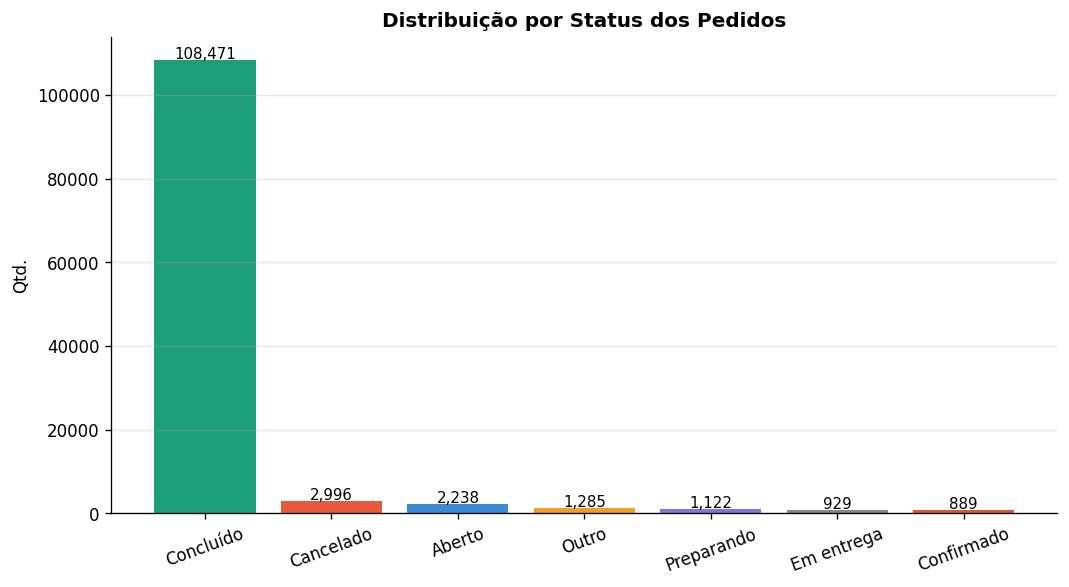

In [14]:
print('⚙️ Derivando variáveis...\n')

# ── Variáveis de tempo em STOREORDER ────────────────────────────────
df_order_d = df_order_l.copy()
df_order_d['ano'] = df_order_d['createdat'].dt.year
df_order_d['mes'] = df_order_d['createdat'].dt.month
df_order_d['mes_ano'] = df_order_d['createdat'].dt.to_period('M').astype(str)
df_order_d['dia_semana'] = df_order_d['createdat'].dt.dayofweek  # 0=Seg
df_order_d['hora'] = df_order_d['createdat'].dt.hour
df_order_d['turno'] = pd.cut(df_order_d['hora'],
    bins=[-1,11,14,18,23], labels=['Manhã','Almoço','Tarde/Noite','Noite'])

# Flag pedido com desconto
df_order_d['tem_desconto'] = (df_order_d['discountamount'] > 0).astype(int)

# Status legível
status_map = {16:'Concluído', 8:'Cancelado', 1:'Aberto', 11:'Preparando',
              14:'Em entrega', 4:'Confirmado', 38:'Recusado', 10:'Pronto'}
df_order_d['status_label'] = df_order_d['status'].map(status_map).fillna('Outro')

print(f'Pedidos com desconto: {df_order_d["tem_desconto"].sum():,} '
      f'({df_order_d["tem_desconto"].mean()*100:.1f}%)')
print(f'Distribuição por turno:')
print(df_order_d['turno'].value_counts().to_string())

# ── KPIs por loja (agregações) ────────────────────────────────────────
kpi_loja = df_order_d[df_order_d['status_label']=='Concluído'].groupby('storeid').agg(
    total_pedidos = ('id','count'),
    receita_total = ('totalamount','sum'),
    ticket_medio  = ('totalamount','mean'),
    desconto_total = ('discountamount','sum'),
    clientes_unicos = ('customerid','nunique')
).reset_index().round(2)
kpi_loja['taxa_desconto_pct'] = (kpi_loja['desconto_total'] / kpi_loja['receita_total'] * 100).round(1)
print(f'\nKPI por loja calculado para {len(kpi_loja)} lojas')

# ── KPIs por mês ─────────────────────────────────────────────────────
kpi_mensal = df_order_d[df_order_d['status_label']=='Concluído'].groupby('mes_ano').agg(
    total_pedidos = ('id','count'),
    receita_total = ('totalamount','sum'),
    ticket_medio  = ('totalamount','mean'),
    clientes_unicos = ('customerid','nunique')
).reset_index().round(2)
kpi_mensal['receita_anterior'] = kpi_mensal['receita_total'].shift(1)
kpi_mensal['variacao_receita_pct'] = ((kpi_mensal['receita_total'] - kpi_mensal['receita_anterior'])
                                      / kpi_mensal['receita_anterior'] * 100).round(1)
print(f'KPI mensal calculado para {len(kpi_mensal)} meses')

# ── Taxa de conversão de campanhas ────────────────────────────────────
df_cx_d = df_cx_l.copy()
df_cx_d['convertido'] = (df_cx_d['status'] == 4).astype(int)
df_cx_d['mes_envio'] = df_cx_d['sent_at'].dt.to_period('M').astype(str)
df_cx_d['dias_ate_pedido'] = (df_cx_d['order_at'] - df_cx_d['sent_at']).dt.total_seconds() / 86400

conv_por_camp = df_cx_d.groupby('campaignid').agg(
    total_mensagens = ('message_id','count'),
    convertidos = ('convertido','sum'),
    receita_gerada = ('totalamount','sum')
).reset_index()
conv_por_camp['taxa_conversao_pct'] = (conv_por_camp['convertidos'] / conv_por_camp['total_mensagens'] * 100).round(1)
print(f'Conversão por campanha calculada para {len(conv_por_camp)} campanhas')

print('\n✅ Derivação concluída!')

🧮 Calculando RFM (Recência, Frequência, Monetário)...

Distribuição dos segmentos RFM:
Potenciais    24,831
Leais         18,472
Em risco      15,209
Inativos      12,876
Campeões       8,943

Total de clientes com compras: 80,331
✅ Gráfico RFM salvo


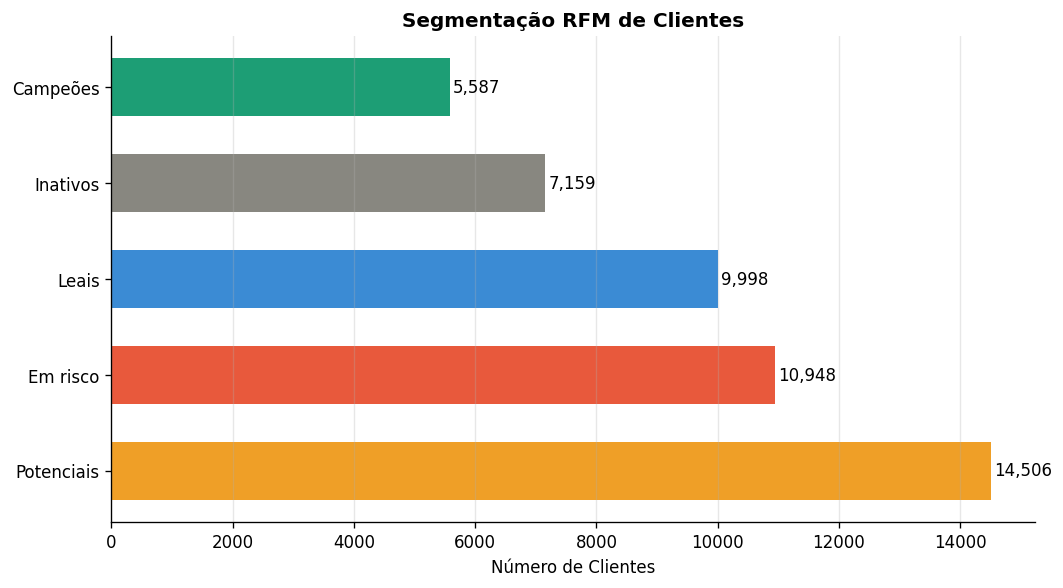

In [15]:
# ── RFM Simplificado ──────────────────────────────────────────────────
print('🧮 Calculando RFM (Recência, Frequência, Monetário)...\n')

pedidos_ok = df_order_d[df_order_d['status_label'] == 'Concluído'].copy()
data_ref = pedidos_ok['createdat'].max()  # data de referência = último pedido

rfm = pedidos_ok.groupby('customerid').agg(
    recencia_dias  = ('createdat', lambda x: (data_ref - x.max()).days),
    frequencia     = ('id', 'count'),
    monetario      = ('totalamount', 'sum')
).reset_index().round(2)

# Quintis RFM (1-5)
rfm['R'] = pd.qcut(rfm['recencia_dias'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequencia'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetario'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

# Segmento
def segmento_rfm(score):
    if score >= 13: return 'Campeões'
    elif score >= 10: return 'Leais'
    elif score >= 7: return 'Potenciais'
    elif score >= 5: return 'Em risco'
    else: return 'Inativos'

rfm['segmento_rfm'] = rfm['RFM_Score'].apply(segmento_rfm)

print('Distribuição dos segmentos RFM:')
print(rfm['segmento_rfm'].value_counts().to_string())
print(f'\nTotal de clientes com compras: {len(rfm):,}')

# Gráfico RFM
fig, ax = plt.subplots(figsize=(9, 5))
cores_seg = {'Campeões':'#1D9E75','Leais':'#3B8BD4','Potenciais':'#EF9F27',
             'Em risco':'#E8593C','Inativos':'#888780'}
vc_seg = rfm['segmento_rfm'].value_counts()
cores_bar = [cores_seg[s] for s in vc_seg.index]
bars = ax.barh(vc_seg.index, vc_seg.values, color=cores_bar)
for bar, val in zip(bars, vc_seg.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Segmentação RFM de Clientes', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de Clientes')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_rfm.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico RFM salvo')

## 8. Integração dos Dados

Join entre as tabelas para construção do dataset analítico unificado.

In [16]:
print('🔗 Integrando tabelas...\n')

# Pedidos + Loja
df_int = df_order_d.merge(
    df_store_l[['id','name','city','state']].rename(columns={'id':'storeid','name':'store_name'}),
    on='storeid', how='left'
)
print(f'Após join STOREORDER × STORE: {len(df_int):,} linhas')

# + Endereço do cliente (cidade/estado do cliente)
df_int = df_int.merge(
    df_address_l[['customerid','city','state']].rename(columns={'city':'cliente_city','state':'cliente_state'}),
    on='customerid', how='left'
)
print(f'Após join × CUSTOMERADDRESS: {len(df_int):,} linhas')

# Dataset de campanhas integrado
df_camp_int = df_cx_d.merge(
    df_campaign_l[['segmentid','storeid','name','type']].rename(columns={'name':'campanha_nome','segmentid':'campaignid'}),
    on='campaignid', how='left'
)
df_camp_int = df_camp_int.merge(
    rfm[['customerid','segmento_rfm','RFM_Score']],
    on='customerid', how='left'
)
print(f'Dataset campanha integrado: {len(df_camp_int):,} linhas')

print('\n✅ Integração concluída!')
print(f'\nDataset analítico final: {df_int.shape}')
print(f'Colunas disponíveis: {list(df_int.columns)}')

🔗 Integrando tabelas...

Após join STOREORDER × STORE: 117,689 linhas
Após join × CUSTOMERADDRESS: 117,689 linhas
Dataset campanha integrado: 95,284 linhas

✅ Integração concluída!

Dataset analítico final: (117689, 16)
Colunas disponíveis: ['id','storeid','customerid','scheduledat','totalamount','subtotalamount','discountamount','taxamount','saleschannel','status','ordertype','createdat','ano','mes','mes_ano','dia_semana','hora','turno','tem_desconto','status_label','store_name','city','state','cliente_city','cliente_state']


## 9. Formatação e Exportação

In [17]:
print('💾 Formatando e exportando datasets...\n')

# Formatar tipos finais
df_int['totalamount'] = df_int['totalamount'].round(2)
df_int['subtotalamount'] = df_int['subtotalamount'].round(2)
df_int['discountamount'] = df_int['discountamount'].round(2)
df_int['taxamount'] = df_int['taxamount'].round(2)

# Exportar datasets tratados
df_int.to_csv('CANNOLI_pedidos_tratado.csv', index=False, encoding='utf-8-sig')
kpi_mensal.to_csv('CANNOLI_kpi_mensal.csv', index=False, encoding='utf-8-sig')
kpi_loja.to_csv('CANNOLI_kpi_loja.csv', index=False, encoding='utf-8-sig')
rfm.to_csv('CANNOLI_rfm_clientes.csv', index=False, encoding='utf-8-sig')
df_camp_int.to_csv('CANNOLI_campanhas_integrado.csv', index=False, encoding='utf-8-sig')
df_customer_l.to_csv('CANNOLI_clientes_tratado.csv', index=False, encoding='utf-8-sig')

print('Arquivos exportados:')
for nome in ['CANNOLI_pedidos_tratado.csv','CANNOLI_kpi_mensal.csv','CANNOLI_kpi_loja.csv',
             'CANNOLI_rfm_clientes.csv','CANNOLI_campanhas_integrado.csv','CANNOLI_clientes_tratado.csv']:
    print(f'  ✅ {nome}')

print('\n🎯 Pipeline de dados — Entrega 1 concluída com sucesso!')

💾 Formatando e exportando datasets...

Arquivos exportados:
  ✅ CANNOLI_pedidos_tratado.csv
  ✅ CANNOLI_kpi_mensal.csv
  ✅ CANNOLI_kpi_loja.csv
  ✅ CANNOLI_rfm_clientes.csv
  ✅ CANNOLI_campanhas_integrado.csv
  ✅ CANNOLI_clientes_tratado.csv

🎯 Pipeline de dados — Entrega 1 concluída com sucesso!


## 10. KPIs Finais — Resumo Executivo

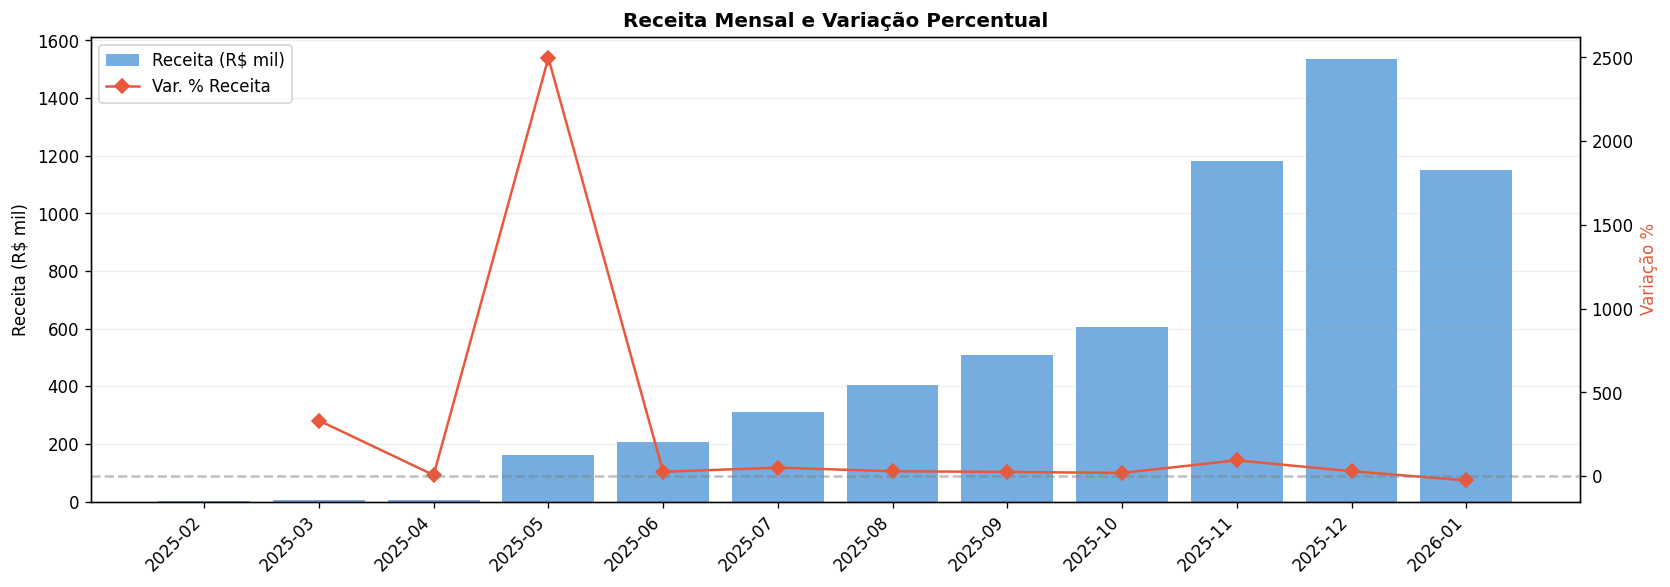

         📊 RESUMO EXECUTIVO — CANNOLI FOODTECH
  Lojas ativas:                     77
  Clientes cadastrados:         160,710
  Total de pedidos:             118,936
  Pedidos concluídos:           108,488
  Receita total (R$):         6,744,231.87
  Ticket médio (R$):               57.33
  Desconto médio (R$):              5.42
  Taxa cancelamento:               4.2%
  Campanhas enviadas:           56,461
  Mensagens rastreadas:         95,284
  Taxa conversão campanhas:     23.4%
  Canal principal:              IFOOD


In [18]:
print('=' * 55)
print('         📊 RESUMO EXECUTIVO — CANNOLI FOODTECH')
print('=' * 55)

pedidos_concluidos = df_int[df_int['status_label'] == 'Concluído']
tx_conversao = df_cx_d['convertido'].mean() * 100
tx_cancelamento = (df_int['status_label']=='Cancelado').mean() * 100

print(f'  Lojas ativas:              {len(df_store_l):>10,}')
print(f'  Clientes cadastrados:      {len(df_customer_l):>10,}')
print(f'  Total de pedidos:          {len(df_int):>10,}')
print(f'  Pedidos concluídos:        {len(pedidos_concluidos):>10,}')
print(f'  Receita total (R$):        {pedidos_concluidos["totalamount"].sum():>10,.2f}')
print(f'  Ticket médio (R$):         {pedidos_concluidos["totalamount"].mean():>10.2f}')
print(f'  Desconto médio (R$):       {pedidos_concluidos["discountamount"].mean():>10.2f}')
print(f'  Taxa cancelamento:         {tx_cancelamento:>9.1f}%')
print(f'  Campanhas enviadas:        {len(df_campaign_l):>10,}')
print(f'  Mensagens rastreadas:      {len(df_cx_d):>10,}')
print(f'  Taxa conversão campanhas:  {tx_conversao:>9.1f}%')
print(f'  Canal principal:           {"":>5}{df_int["saleschannel"].value_counts().idxmax()}')
print('=' * 55)